# 2단계 — 전처리 파이프라인

원시 이메일 텍스트를 정제하여 모델에 입력할 수 있는 형태로 변환합니다.

처리 순서:
1. HTML 태그 제거
2. URL → `[URL]` 토큰
3. 이메일 주소 → `[EMAIL]` 토큰
4. 전화번호 → `[PHONE]` 토큰
5. 특수문자 정리
6. 소문자 변환
7. 공백 정규화

In [1]:
import sys
sys.path.insert(0, '..')

from src.data.preprocessor import Preprocessor

pre = Preprocessor(use_konlpy=False)
print('Preprocessor 준비 완료')

Preprocessor 준비 완료


## HTML 태그 제거

In [2]:
html_text = '<h1>특별 이벤트</h1><p>지금 <b>클릭</b>하세요! <a href="http://spam.com">바로가기</a></p>'
cleaned = pre.clean(html_text)

print('[입력]', html_text)
print('[출력]', cleaned)

[입력] <h1>특별 이벤트</h1><p>지금 <b>클릭</b>하세요! <a href="http://spam.com">바로가기</a></p>
[출력] 특별 이벤트 지금 클릭 하세요 바로가기


## URL / 이메일 / 전화번호 토큰 치환

In [ ]:
text = '자세한 내용은 https://spam-site.com/offer?ref=abc 확인 후 spam@bad.com 또는 010-9876-5432 로 연락주세요.'
cleaned = pre.clean(text)

print('[입력]', text)
print('[출력]', cleaned)

[입력] 자세한 내용은 https://spam-site.com/offer?ref=abc 확인 후 spam@bad.com 또는 010-9876-5432 로 연락주세요.
[출력] 자세한 내용은 [url] 확인 후 [email] 또는 [phone] 로 연락주세요


## 전체 전처리: preprocess(subject, body)

In [4]:
subject = '[당첨] 1억원 무료 지급 이벤트!!!'
body = '''
<p>안녕하세요 고객님,</p>
<p>축하합니다! 귀하께서 <b>특별 이벤트</b>에 당첨되셨습니다.</p>
<p>지금 바로 https://free-money.co.kr/claim?token=xyz123 에서 수령하세요.</p>
<p>문의: winner@free-money.co.kr | 010-0000-1234</p>
'''

result = pre.preprocess(subject, body)
print('[제목]', subject)
print('[전처리 결과]')
print(result)

[제목] [당첨] 1억원 무료 지급 이벤트!!!
[전처리 결과]
[당첨] 1억원 무료 지급 이벤트 안녕하세요 고객님 축하합니다 귀하께서 특별 이벤트 에 당첨되셨습니다 지금 바로 [url] 에서 수령하세요 문의 [email] [phone]


## 데이터셋 전체에 전처리 적용

In [7]:
import pandas as pd
from src.data.loader import load_dataset

data = load_dataset(
    csv_path='../data/korean_spam_dataset.csv',
    preprocessor=pre,
    train_ratio=0.8,
    val_ratio=0.1,
    random_state=42,
)

[데이터] 총 5000개 로드 | 스팸: spamspamhamspamhamspamspamspamspamspamhamspamspamspamhamhamspamhamspamhamhamhamspamhamhamspamhamhamspamspamspamhamhamspamhamhamspamspamspamspamhamhamhamhamspamspamspamhamhamspamspamhamspamspamhamspamspamhamhamspamspamhamhamhamhamspamhamhamspamhamhamhamhamspamspamhamhamhamhamspamspamspamhamhamhamspamhamhamhamspamspamspamhamspamspamhamhamspamspamhamspamhamhamhamspamhamspamhamhamhamhamspamhamhamhamspamhamhamspamhamhamhamspamspamhamhamspamspamspamhamspamspamspamhamspamspamhamhamspamhamhamhamhamspamhamspamspamhamspamspamhamspamhamspamspamspamspamhamspamhamhamspamhamhamhamspamspamspamhamspamhamhamspamhamhamspamhamhamspamhamhamspamspamhamhamhamspamhamhamspamhamhamspamhamhamhamspamhamhamspamhamspamhamspamspamhamspamhamhamhamhamhamhamspamhamhamhamhamspamspamhamhamspamspamspamspamspamspamhamspamhamspamspamspamspamhamspamhamspamhamspamhamhamhamspamspamhamhamspamspamhamhamspamhamhamspamhamhamhamhamspamspamspamhamhamspamspamhamspamspamhamspamspamhamhamhamhamhamspamspamspamspa

In [8]:
print('train 샘플 수:', len(data.X_train))
print('val   샘플 수:', len(data.X_val))
print('test  샘플 수:', len(data.X_test))

print('\n--- train 샘플 ---')
for i in range(3):
    label = '스팸' if data.y_train[i] == 1 else '정상'
    print(f'[{label}] {data.X_train[i][:100]}...')

train 샘플 수: 4000
val   샘플 수: 500
test  샘플 수: 500

--- train 샘플 ---
[정상] re 지난번 말씀하신 건 관련해서요 안녕하세요 생일 파티와 관련해서 몇 가지 여쭤보고 싶은 게 있어서요 시간 되실 때 답변 주시면 감사하겠습니다 좋은 하루 보내세요...
[정상] 이번 주 핀테크 트렌드 정리 이벤트나라 주간 뉴스레터입니다 이번 주 주요 내용 디자인 트렌드 2024년 키워드 분석 마케팅 자동화 도구 비교 분석 마케팅 자동화 도구 비교 분석 질...
[정상] 오늘만 특별 저금리 9 3 대출 안내 안녕하세요 스마트론입니다 한서준님의 신용점수를 조회한 결과 200만원 대출이 가능하십니다 지금 신청하시면 5 1 특별금리 적용 상담전화 014...


## 전처리 전/후 길이 비교

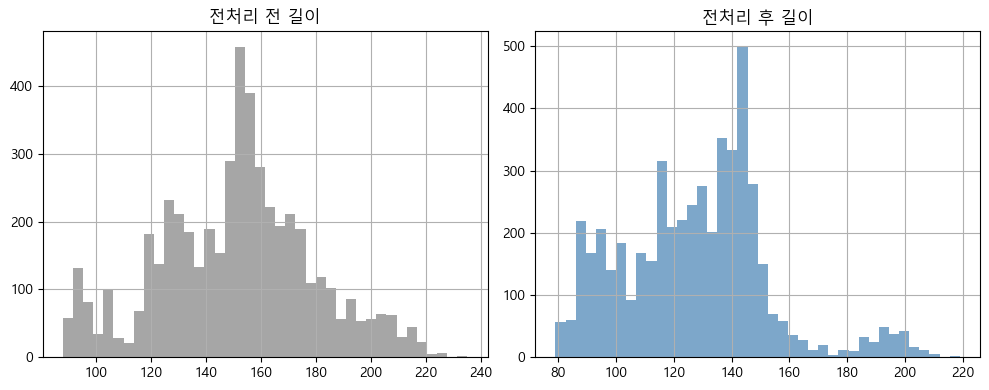

평균 길이: 151 → 127 문자 (15.8% 감소)


In [9]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('../data/korean_spam_dataset.csv', encoding='utf-8-sig')
df['raw_len'] = (df['subject'] + ' ' + df['body']).str.len()
cleaned_lens = [len(pre.preprocess(row['subject'], row['body'])) for _, row in df.iterrows()]
df['clean_len'] = cleaned_lens

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df['raw_len'].hist(bins=40, ax=axes[0], color='gray', alpha=0.7)
axes[0].set_title('전처리 전 길이')
df['clean_len'].hist(bins=40, ax=axes[1], color='steelblue', alpha=0.7)
axes[1].set_title('전처리 후 길이')
plt.tight_layout()
plt.show()

reduction = (1 - df['clean_len'].mean() / df['raw_len'].mean()) * 100
print(f'평균 길이: {df["raw_len"].mean():.0f} → {df["clean_len"].mean():.0f} 문자 ({reduction:.1f}% 감소)')